<a href="https://colab.research.google.com/github/rashmib21/Data-Analysis-of-Stock-Market-from-2016-to-2026/blob/main/closing_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading data from hindustan_copper.ods...
Data loaded successfully.

--- Data Preprocessing Complete ---
DataFrame head:
                             symbol   open   high   low  close   volume
datetime                                                               
2016-01-04 00:00:00+05:30  HINDALCO  84.20  85.90  80.4  80.75  8706224
2016-01-05 00:00:00+05:30  HINDALCO  82.00  83.95  80.6  82.60  9819068
2016-01-06 00:00:00+05:30  HINDALCO  82.40  82.85  79.7  80.55  6494446
2016-01-07 00:00:00+05:30  HINDALCO  79.00  79.40  76.1  76.65  8098318
2016-01-08 00:00:00+05:30  HINDALCO  77.45  78.15  75.2  76.90  6800939
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2671 entries, 2016-01-04 00:00:00+05:30 to 2026-03-30 00:00:00+05:30
Freq: B
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   symbol  2671 non-null   object 
 1   open    2671 non-null   float64
 2   high    2671 non-null   float64
 3   low     2671 non-null  

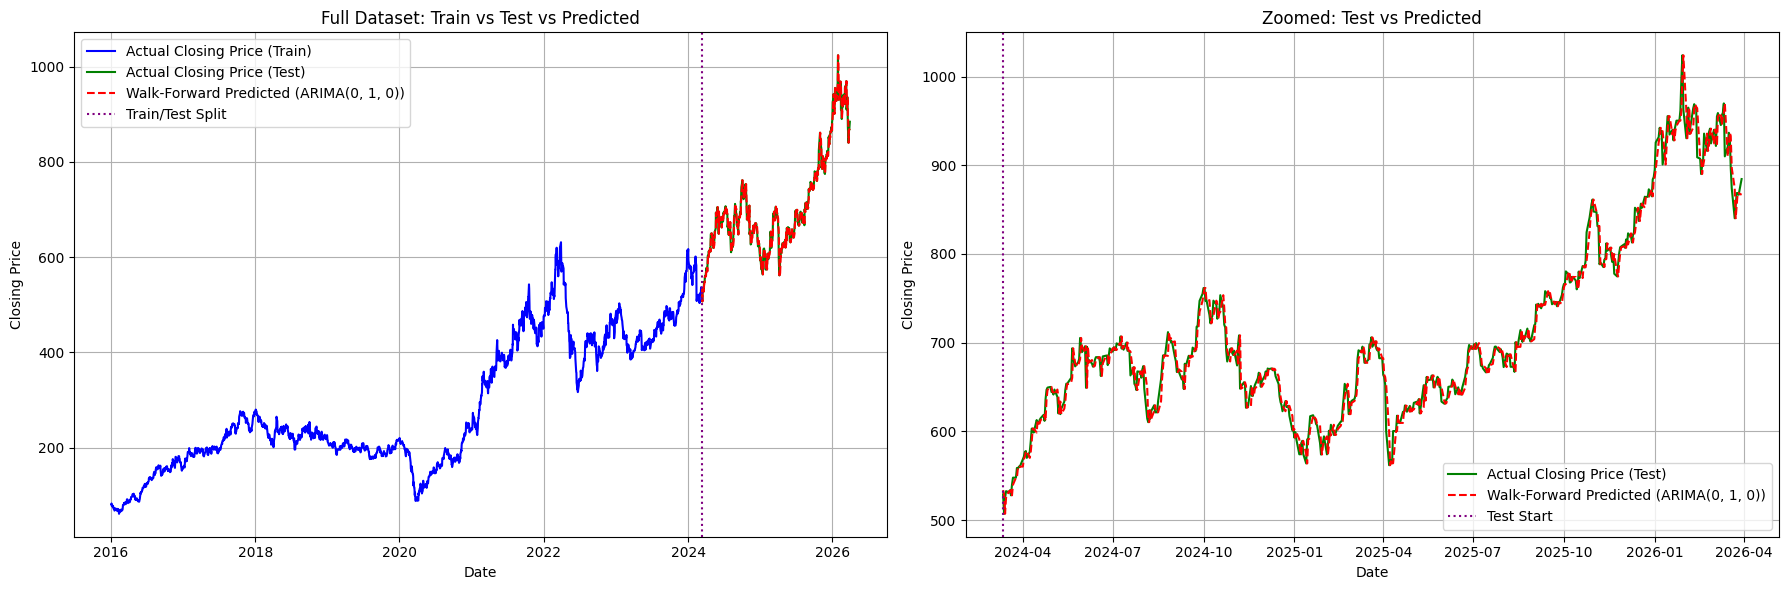


--- Final Summary for Walk-Forward Validation ---
ARIMA Order used: (0, 1, 0)
Final RMSE for Walk-Forward Validation: 13.056


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt
import numpy as np

# --- Step 1: Install odfpy if needed and load the data ---
%pip install --quiet odfpy pmdarima

print("Loading data from hindustan_copper.ods...")
df = pd.read_excel('/content/Hindustan_copper.ods', engine='odf')
print("Data loaded successfully.")

# --- Step 2: Preprocess the data ---
# Parse the datetime column as a proper datetime object
df['datetime'] = pd.to_datetime(df['datetime'])

# Set it as the DataFrame index
df.set_index('datetime', inplace=True)

# Sort the index to ensure time order
df.sort_index(inplace=True)

# Assign business day frequency ('B') and forward-fill missing values
# This is crucial for time series models to avoid warnings and ensure consistent frequency
df = df.asfreq('B', method='ffill')

# Extract the 'close' price series for time series analysis
close_price = df['close']

print("\n--- Data Preprocessing Complete ---")
print(f"DataFrame head:\n{df.head()}")
print(f"DataFrame info:\n{df.info()}")
print(f"Close price series head:\n{close_price.head()}")

# --- Step 3: Check stationarity using the Augmented Dickey-Fuller (ADF) test ---
print("\n--- Performing Augmented Dickey-Fuller Test for Stationarity ---")
# Drop any NaN values that might result from asfreq, especially at the start
close_price_dropna = close_price.dropna()
result = adfuller(close_price_dropna)

print(f'ADF Statistic: {result[0]:.3f}')
print(f'p-value: {result[1]:.3f}')
print('Critical Values:')
for key, value in result[4].items():
    print(f'\t{key}: {value:.3f}')

# Interpret the results
if result[1] <= 0.05:
    print("Conclusion: The series is stationary (reject H0).")
else:
    print("Conclusion: The series is not stationary (fail to reject H0). ARIMA models will likely require differencing (d > 0).")

# --- Step 4: Split the data into 80% training and 20% test sets ---
train_size = int(len(close_price) * 0.8)
train, test = close_price[0:train_size], close_price[train_size:]

print(f"\n--- Data Split Complete ---")
print(f"Train set size: {len(train)}")
print(f"Test set size: {len(test)}")

# --- Step 5: Use auto_arima to find the best (p, d, q) parameters ---
print("\n--- Finding best ARIMA parameters using auto_arima (this may take a moment) ---")
stepwise_model = auto_arima(train, start_p=0, start_q=0, max_p=5, max_q=5,
                            d=None, # Let auto_arima determine differencing order
                            seasonal=False, # Assuming no strong seasonality based on initial prompt
                            trace=False, # Set to True to see individual model fits
                            error_action='ignore',
                            suppress_warnings=True,
                            stepwise=True)

best_order = stepwise_model.order # auto_arima will determine the best order
print(f"Best ARIMA parameters (p, d, q) using auto_arima: {best_order}")

# --- Step 6: Implement Walk-Forward Validation ---
print("\n--- Performing Walk-Forward Validation ---")

history = [x for x in train]
predictions = list()

# Walk-forward validation
for t in range(len(test)):
    # Fit ARIMA model on the current history
    model = ARIMA(history, order=best_order)
    model_fit = model.fit()

    # Predict the next step
    yhat = model_fit.predict(start=len(history), end=len(history))[0]
    predictions.append(yhat)

    # Add actual observation to history for the next iteration
    obs = test.iloc[t] # Changed to .iloc for position-based indexing
    history.append(obs)
    print(f'predicted={yhat:.2f}, expected={obs:.2f}')

# Convert predictions to a pandas Series with the test set's index
predictions_series = pd.Series(predictions, index=test.index)

# --- Step 7: Calculate RMSE for walk-forward predictions ---
rmse_walk_forward = sqrt(mean_squared_error(test, predictions_series))
print(f"\n--- Walk-Forward Model Evaluation ---")
print(f'Root Mean Squared Error (RMSE) for Walk-Forward Validation: {rmse_walk_forward:.3f}')

# --- Step 8: Plot the results of walk-forward validation ---
print("\n--- Plotting Walk-Forward Results ---")
plt.figure(figsize=(18, 6)) # Set overall figure size

# Plot 1: Full View (Train + Test)
plt.subplot(1, 2, 1)
plt.plot(train.index, train, label='Actual Closing Price (Train)', color='blue', linewidth=1.5)
plt.plot(test.index, test, label='Actual Closing Price (Test)', color='green', linewidth=1.5)
plt.plot(predictions_series.index, predictions_series, label=f'Walk-Forward Predicted (ARIMA{best_order})', color='red', linestyle='--', linewidth=1.5)
plt.axvline(x=train.index[-1], color='purple', linestyle=':', label='Train/Test Split')
plt.title('Full Dataset: Train vs Test vs Predicted')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()
plt.grid(True)

# Plot 2: Test Only (Zoomed View)
plt.subplot(1, 2, 2)
plt.plot(test.index, test, label='Actual Closing Price (Test)', color='green', linewidth=1.5)
plt.plot(predictions_series.index, predictions_series, label=f'Walk-Forward Predicted (ARIMA{best_order})', color='red', linestyle='--', linewidth=1.5)
plt.axvline(x=test.index[0], color='purple', linestyle=':', label='Test Start') # Vertical line at the start of the test set
plt.title('Zoomed: Test vs Predicted')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()
plt.grid(True)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

# --- Final Output ---
print("\n--- Final Summary for Walk-Forward Validation ---")
print(f"ARIMA Order used: {best_order}")
print(f"Final RMSE for Walk-Forward Validation: {rmse_walk_forward:.3f}")